## importing libraries

In [2]:
import seaborn as sns
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

### load dataset

In [3]:
df = pd.read_csv(r'c:\Users\Alyna\Downloads\mental_health_data.csv')

In [4]:
df.shape #look for rows and columns


(5000, 13)

In [5]:
#look for first 5 rows
df.head(5)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


### data cleaning

In [6]:
df.isnull().sum()
df.duplicated().sum()

np.int64(2)

In [7]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


### Exploratory Data Analysis

### 1. Distribution of target  (Mental_Health_Score)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

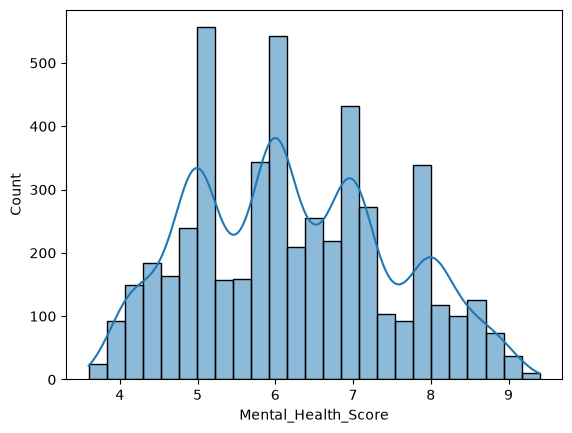

In [8]:
sns.histplot(df['Mental_Health_Score'], kde=True)

### correalation heatmap

<Axes: >

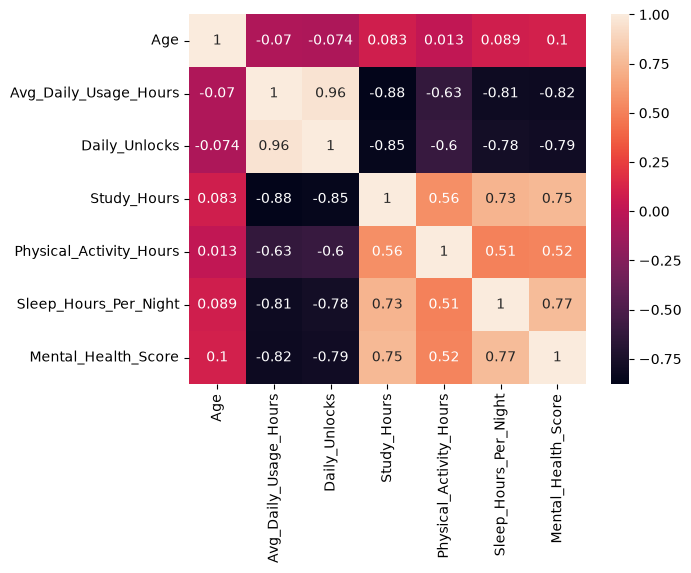

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### 4.3 stress level vs mental health score

In [10]:
df['Stress_Level'].unique()

<StringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

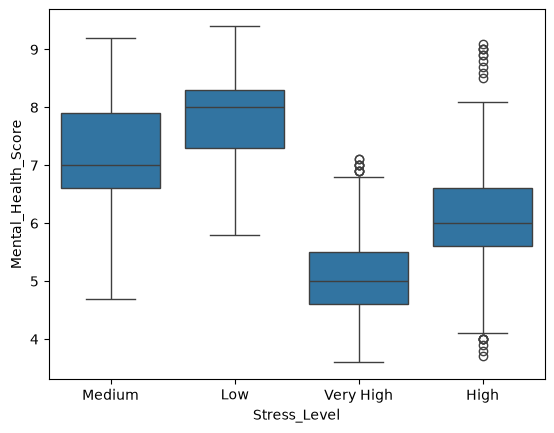

In [11]:
order = ['Medium', 'Low', 'Very High', 'High']
sns.boxplot(x = 'Stress_Level', y = 'Mental_Health_Score', data=df, order=order)

###  4.4  daily usage hours vs mental health score

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

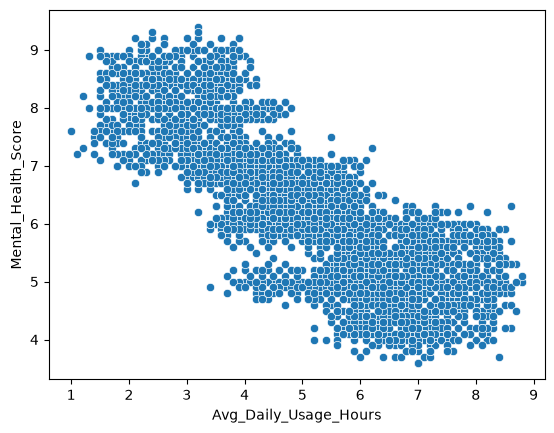

In [12]:
df['Avg_Daily_Usage_Hours'].unique()
sns.scatterplot(x = "Avg_Daily_Usage_Hours", y="Mental_Health_Score", data=df)

### sleep hours vs mental health score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

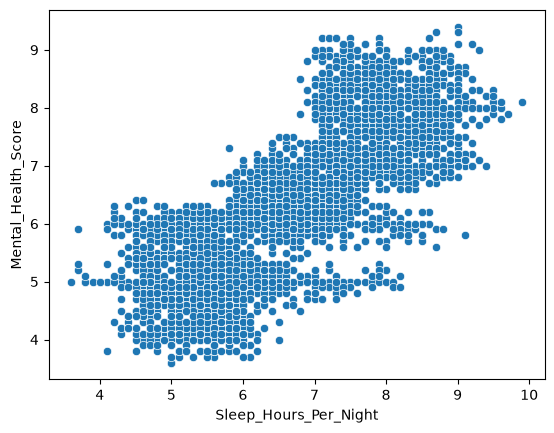

In [13]:
sns.scatterplot(x = "Sleep_Hours_Per_Night", y="Mental_Health_Score", data=df)

In [14]:
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

### most used platform

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

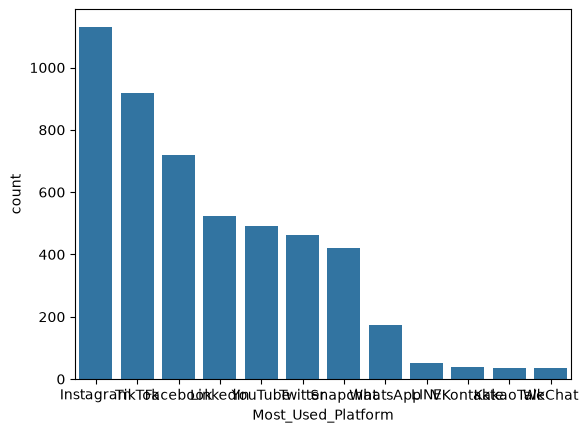

In [15]:
sns.countplot(x='Most_Used_Platform', data=df, order =df['Most_Used_Platform'].value_counts().index)

### checking outliers


In [16]:
num_features = df.select_dtypes(include='number')  #int64
num_features


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [17]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
IQR

lower_bound = Q1 -(1.5 *IQR)
upper_bound = Q3 +(1.5 *IQR)
lower_bound

Age                        14.50
Avg_Daily_Usage_Hours       0.05
Daily_Unlocks              44.00
Study_Hours                -2.55
Physical_Activity_Hours    -0.05
Sleep_Hours_Per_Night       2.75
Mental_Health_Score         2.10
dtype: float64

In [18]:
outliers = (num_features< lower_bound) | (num_features> upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


## Data Cleaning

In [19]:
# 1. Drop Duplicates
dff =df.drop_duplicates()


In [20]:
# 2. converting negative and unrealistic value to realistic value
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)
df.describe()


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751400,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.667274,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## skewness

In [21]:
nums_col = df.select_dtypes(include='number')
nums_col.skew()

# near to 0 = center
# positive = right skewed 
# negative = left skewed 


Age                        0.155325
Avg_Daily_Usage_Hours      0.005606
Daily_Unlocks              0.002351
Study_Hours                0.435819
Physical_Activity_Hours    0.052632
Sleep_Hours_Per_Night      0.124050
Mental_Health_Score        0.206567
dtype: float64

## Feature Engineering

In [22]:
top_countries = df['Country'].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [23]:
def group_countries(Country):
    if Country in top_countries:
        return Country
    else:
        return 'Other'

In [24]:
df['grouped_countries'] = df['Country'].apply(group_countries)
df['grouped_countries'].value_counts()

grouped_countries
Other        3232
India         389
USA           355
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

## Train Test Split

In [25]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'grouped_countries'],
      dtype='str')

In [26]:
from sklearn.model_selection import  train_test_split
skewed_cols = ['Study_Hours']
other_numeric_cols = ["Age", "Sleep_Hours_Per_Night", "Daily_Unlocks", "Physical_Activity_Hours", "Avg_Daily_Usage_Hours"]

ordinal_col = ['Stress_Level']
normal_cols = ["Gender", "Most_Used_Platform", "grouped_countries", "Purpose_Of_Use", "Academic_Level"]

feature_cols = skewed_cols + other_numeric_cols + ordinal_col+ normal_cols
X = df[feature_cols]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## PREPROCESSING USING COLUMNTRANSFORMER

### Build  a Pipeline

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

# 2. Numeric features
numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

# 3. Ordinal features
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(
        categories=[['Low', 'Medium', 'High', 'Very High']]
    ))
])

# 4. Normal categorical features
normal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[

    ("Skewed Pipeline", skew_pipeline, skewed_cols),

    ("Plain Numeric", numeric_pipeline, other_numeric_cols),

    ("Ordinal Pipeline", ordinal_pipeline, ordinal_col),

    ("Normal Pipeline", normal_pipeline, normal_cols)

])


### Baseline: Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the pipeline
lr_pipeline.fit(X_train, y_train)

# Predictions
lr_preds_test= lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

# R² scores
lr_r2_testing  = r2_score(y_test, lr_preds_test)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds_test)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')
     


Accuracy of Training 0.7181441215388289
Accuracy of Testing 0.7529733201603577
MAE 0.5131589482163137


## Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train, y_train)
rf_preds_test= rf_pipeline.predict(X_test)
rf_preds_train= rf_pipeline.predict(X_train)

rf_r2_testing  = r2_score(y_test, rf_preds_test)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mae         = mean_absolute_error(y_test, rf_preds_test)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f'MAE {rf_mae}')

Accuracy of Training 0.9814939166070755
Accuracy of Testing 0.8814045704585907
MAE 0.33975202222222234


## HyperParamater tuning the random forest

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_grid= {
    'random forest__n_estimators' : [100,200,300],
    'random forest__max_depth' :[5,10,15],
    'random forest__min_samples_leaf' : [1,2,4],
    'random forest__min_samples_split': [2,5,10]
}

random_search = RandomizedSearchCV(
     estimator = rf_pipeline,
     param_distributions= param_grid,
     n_iter = 15,
     cv= 5,
     random_state= 42,
     n_jobs= -1 ,# processor which are free
     scoring='r2'

)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random forest__max_depth': [5, 10, ...], 'random forest__min_samples_leaf': [1, 2, ...], 'random forest__min_samples_split': [2, 5, ...], 'random forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [31]:
random_search.best_params_

{'random forest__n_estimators': 300,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [32]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds =  rf_best_pipeline.predict(X_test)


print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8695977365955029
MAE Score for random forest after hyperparameter tuning 0.3600894860009965


### model evaluation

In [33]:

from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds_test))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds_test))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.752973     0.718144  0.513159  0.653412
1  Random Forest (default)  0.881405     0.981494  0.339752  0.452740
2    Random Forest (tuned)  0.869598     0.956638  0.360089  0.474742


## save model

In [34]:
import shap

c:\Users\Alyna\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
# ============================================================
# SHAP EXPLAINABILITY - SETUP
# ============================================================

# Use the trained Random Forest pipeline
best_pipeline = rf_pipeline

# Extract the fitted preprocessor
preprocessor = best_pipeline.named_steps["preprocessor"]

# Extract the fitted Random Forest model
rf_model = best_pipeline.named_steps["random forest"]

print("Pipeline and Random Forest model loaded successfully!")

Pipeline and Random Forest model loaded successfully!


In [36]:
# ============================================================
# TRANSFORM TEST DATA FOR SHAP
# ============================================================

X_test_transformed = preprocessor.transform(X_test)

# Convert sparse matrix to dense array if needed
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

print("Transformed data shape:", X_test_transformed.shape)

Transformed data shape: (1500, 38)


In [37]:
print(type(preprocessor))
print(preprocessor)

print("\nAVAILABLE ATTRIBUTES:")
print([x for x in dir(preprocessor) if "transform" in x])

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
ColumnTransformer(transformers=[('Skewed Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('Plain Numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Sleep_Hours_Per_Night',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Avg_Daily_Usage_Hours']),
                                ('Ordinal Pipeline',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                           

In [38]:
# ============================================================
# CREATE FEATURE NAMES FOR SHAP
# ============================================================

feature_names = []

# 1. Skewed columns
feature_names.extend(skewed_cols)

# 2. Other numerical columns
feature_names.extend(other_numeric_cols)

# 3. Ordinal columns
feature_names.extend(ordinal_col)

# 4. Nominal columns after One-Hot Encoding

# Get the fitted "Normal Pipeline"
nominal_transformer = preprocessor.named_transformers_["Normal Pipeline"]

# Get the fitted OneHotEncoder
onehot_encoder = nominal_transformer.named_steps["encode"]

# Generate feature names for the one-hot encoded columns
onehot_feature_names = onehot_encoder.get_feature_names_out(
    normal_cols
)

# Add those names
feature_names.extend(list(onehot_feature_names))


# Check that both counts match
print("Number of transformed columns:", X_test_transformed.shape[1])
print("Number of feature names:", len(feature_names))

Number of transformed columns: 38
Number of feature names: 38


In [39]:
# ============================================================
# CREATE SHAP DATA AND EXPLAINER
# ============================================================

# Convert transformed test data into a DataFrame
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# Create SHAP explainer for the trained Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values
shap_values = explainer(X_test_shap)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


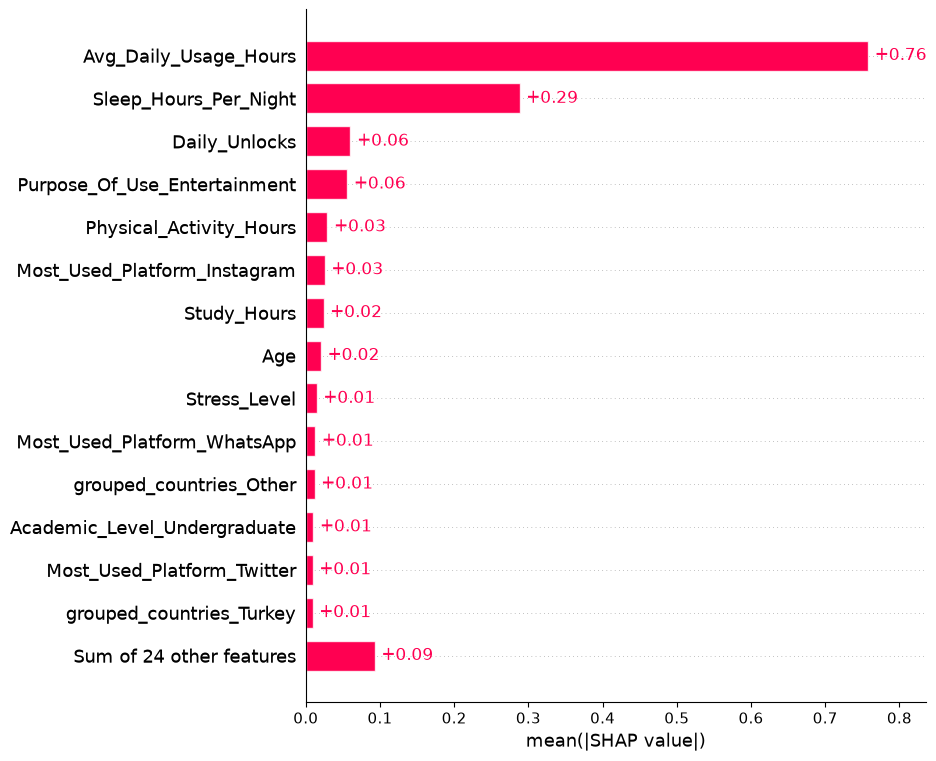

In [40]:
# ============================================================
# GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=15
)

STUDENT INPUT DATA:


,Study_Hours,Age,Sleep_Hours_Per_Night,Daily_Unlocks,Physical_Activity_Hours,Avg_Daily_Usage_Hours,Stress_Level,Gender,Most_Used_Platform,grouped_countries,Purpose_Of_Use,Academic_Level
1501,2.7,21,7.8,145,2.6,4.5,High,Male,WeChat,Other,Entertainment,Undergraduate



Predicted Mental Health Score: 6.63


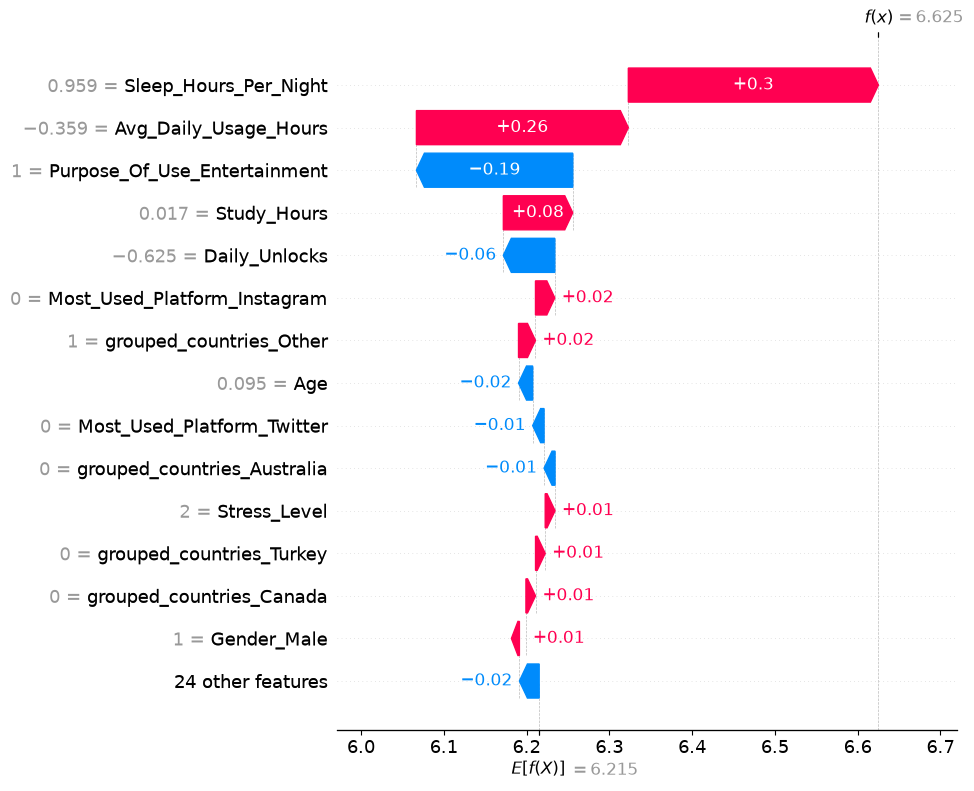

In [41]:
# ============================================================
# EXPLAIN ONE INDIVIDUAL STUDENT PREDICTION
# ============================================================

# Choose a student from the test dataset
student_index = 0


# ------------------------------------------------------------
# SHOW THE ORIGINAL INPUT DATA
# ------------------------------------------------------------

print("STUDENT INPUT DATA:")

display(
    X_test.iloc[[student_index]]
)


# ------------------------------------------------------------
# MAKE PREDICTION USING THE COMPLETE PIPELINE
# ------------------------------------------------------------

prediction = best_pipeline.predict(
    X_test.iloc[[student_index]]
)[0]


print("\nPredicted Mental Health Score:",
      round(float(prediction), 2))


# ------------------------------------------------------------
# SHOW SHAP WATERFALL EXPLANATION
# ------------------------------------------------------------

shap.plots.waterfall(
    shap_values[student_index],
    max_display=15
)

In [42]:
# ============================================================
# READABLE SHAP EXPLANATION FOR ONE STUDENT
# ============================================================

# Get SHAP contributions for the selected student
student_contributions = shap_values.values[student_index]


# Create a DataFrame
explanation_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Contribution": student_contributions
})


# Calculate absolute impact
explanation_df["Absolute_Impact"] = (
    explanation_df["SHAP_Contribution"].abs()
)


# Sort from strongest impact to weakest
explanation_df = explanation_df.sort_values(
    by="Absolute_Impact",
    ascending=False
)


# Show the top 15 most important factors
display(explanation_df.head(15))

,Feature,SHAP_Contribution,Absolute_Impact
2,Sleep_Hours_Per_Night,0.302076,0.302076
5,Avg_Daily_Usage_Hours,0.255982,0.255982
32,Purpose_Of_Use_Entertainment,-0.188852,0.188852
0,Study_Hours,0.083856,0.083856
3,Daily_Unlocks,-0.062184,0.062184
10,Most_Used_Platform_Instagram,0.023352,0.023352
27,grouped_countries_Other,0.020490,0.020490
1,Age,-0.017090,0.017090
16,Most_Used_Platform_Twitter,-0.013764,0.013764
21,grouped_countries_Australia,-0.013264,0.013264


In [43]:
# ============================================================
# SEPARATE FACTORS LOWERING AND INCREASING THE PREDICTION
# ============================================================

# Factors that pushed the prediction DOWN
negative_factors = explanation_df[
    explanation_df["SHAP_Contribution"] < 0
].head(5)


# Factors that pushed the prediction UP
positive_factors = explanation_df[
    explanation_df["SHAP_Contribution"] > 0
].head(5)


# ------------------------------------------------------------
# DISPLAY FACTORS LOWERING THE SCORE
# ------------------------------------------------------------

print("FACTORS THAT PUSHED THE PREDICTED SCORE LOWER:")

display(
    negative_factors[
        ["Feature", "SHAP_Contribution"]
    ]
)


# ------------------------------------------------------------
# DISPLAY FACTORS INCREASING THE SCORE
# ------------------------------------------------------------

print("FACTORS THAT PUSHED THE PREDICTED SCORE HIGHER:")

display(
    positive_factors[
        ["Feature", "SHAP_Contribution"]
    ]
)

FACTORS THAT PUSHED THE PREDICTED SCORE LOWER:


,Feature,SHAP_Contribution
32,Purpose_Of_Use_Entertainment,-0.188852
3,Daily_Unlocks,-0.062184
1,Age,-0.017090
16,Most_Used_Platform_Twitter,-0.013764
21,grouped_countries_Australia,-0.013264


FACTORS THAT PUSHED THE PREDICTED SCORE HIGHER:


,Feature,SHAP_Contribution
2,Sleep_Hours_Per_Night,0.302076
5,Avg_Daily_Usage_Hours,0.255982
0,Study_Hours,0.083856
10,Most_Used_Platform_Instagram,0.023352
27,grouped_countries_Other,0.020490


In [44]:
# ============================================================
# HUMAN-READABLE EXPLANATION
# ============================================================

# Create lists for readable explanations

lowering_features = negative_factors["Feature"].tolist()

increasing_features = positive_factors["Feature"].tolist()


# ------------------------------------------------------------
# PRINT FINAL EXPLANATION
# ------------------------------------------------------------

print("=" * 60)
print("MENTAL HEALTH SCORE EXPLANATION")
print("=" * 60)


print(
    f"\nPredicted Mental Health Score: "
    f"{round(float(prediction), 2)}"
)


# Factors lowering the prediction
print("\nFactors that pushed the prediction LOWER:")

if len(lowering_features) > 0:

    for feature in lowering_features:
        print(f"- {feature}")

else:
    print("- No major factors pushed the prediction lower.")


# Factors increasing the prediction
print("\nFactors that pushed the prediction HIGHER:")

if len(increasing_features) > 0:

    for feature in increasing_features:
        print(f"- {feature}")

else:
    print("- No major factors pushed the prediction higher.")


print("\nNote:")
print(
    "These factors explain how the machine learning model "
    "arrived at this prediction. They do not prove that a "
    "feature directly caused a change in mental health."
)

print("=" * 60)

MENTAL HEALTH SCORE EXPLANATION

Predicted Mental Health Score: 6.63

Factors that pushed the prediction LOWER:
- Purpose_Of_Use_Entertainment
- Daily_Unlocks
- Age
- Most_Used_Platform_Twitter
- grouped_countries_Australia

Factors that pushed the prediction HIGHER:
- Sleep_Hours_Per_Night
- Avg_Daily_Usage_Hours
- Study_Hours
- Most_Used_Platform_Instagram
- grouped_countries_Other

Note:
These factors explain how the machine learning model arrived at this prediction. They do not prove that a feature directly caused a change in mental health.


In [46]:
import joblib

joblib.dump(
    rf_pipeline,
    "Mental_Health_Model.pkl"
)

['Mental_Health_Model.pkl']